# Event Selection

**_must run with dfs will all reconstructed slices_**

This notebook runs the full event selection, evaluating selection performance

- makes mode breakdown bar plots for each selection stage
- makes purity/efficiency summary plots

In [37]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
import numpy as np
import sys
from os import path, makedirs
from datetime import datetime

# local imports
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana') # absolute path for running on EAF
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.categories import *
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.makedf.selections import *
from pyanalib.split_df_helpers import *
from pyanalib.pandas_helpers import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 
plt.style.use("presentation.mplstyle")

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

In [2]:
save_fig = False
show_plot = True

save_fig_base_dir = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi"
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "event_selection-{}".format(today_str))

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

In [3]:
n_max_concat = 3
file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09"

## -- MC 
generator = "GENIE"
mc_keys2load = ['hdr', 'evt', 'trk', 'mcnu']
concat_dfs = load_and_concat_mc_dfs(
    file_dir=file_dir,
    chunk_tags=generate_tags("ad"),
    df_tag="_all",
    keys2load=mc_keys2load,
    n_max_concat=n_max_concat,
    sub_dir="MC",
    sample_dir="BNB_cosmics"
)
mc_hdr_df = concat_dfs['hdr']
mc_evt_df = concat_dfs['evt']
mc_trk_df = concat_dfs['trk']
mc_mcnu_df = concat_dfs['mcnu']

## -- low E MC
concat_dfs = load_and_concat_mc_dfs(
    file_dir=file_dir,
    chunk_tags=generate_tags("ad"),
    df_tag="_all",
    keys2load=mc_keys2load,
    n_max_concat=n_max_concat,
    sub_dir="MC",
    sample_dir="lowE"
)
dirt_hdr_df = concat_dfs['hdr']
dirt_evt_df = concat_dfs['evt']
dirt_trk_df = concat_dfs['trk']
dirt_mcnu_df = concat_dfs['mcnu']

## -- Data
data_file = path.join(file_dir, "data", "BNB", "all.df")
data_split_df = pd.read_hdf(data_file, key="split")
data_n_split = get_n_split(data_file)
print("data_n_split: %d" %(data_n_split))
print_keys(data_file)
data_keys2load = ['evt', 'trk', 'hdr', 'bnbpot']
data_dfs = load_dfs(data_file, data_keys2load, n_max_concat=n_max_concat)
data_evt_df = data_dfs['evt']
data_trk_df = data_dfs['trk']
data_hdr_df = data_dfs['hdr']
data_bnbpot_df = data_dfs['bnbpot']

## -- Intime Data
# intime_keys2load = ['hdr', 'evt', 'trk']
# concat_dfs = load_and_concat_mc_dfs(
#     file_dir=file_dir,
#     chunk_tags=["test"],
#     df_tag="_all",
#     keys2load=intime_keys2load,
#     n_max_concat=n_max_concat,
#     sub_dir="data",
#     sample_dir="OffBeam"
# )
# intime_hdr_df = concat_dfs['hdr']
# intime_evt_df = concat_dfs['evt']
# intime_trk_df = concat_dfs['trk']

## -- Intime MC
intime_keys2load = ['hdr', 'evt', 'trk']
concat_dfs = load_and_concat_mc_dfs(
    file_dir=file_dir,
    chunk_tags=generate_tags("ag"),
    df_tag="_all",
    keys2load=intime_keys2load,
    n_max_concat=n_max_concat,
    sub_dir="MC",
    sample_dir="intime"
)
intime_hdr_df = concat_dfs['hdr']
intime_evt_df = concat_dfs['evt']
intime_trk_df = concat_dfs['trk']

Reading file with tag aa, mc_n_split: 3
Keys: ['/evt_0', '/evt_1', '/evt_2', '/hdr_0', '/hdr_1', '/hdr_2', '/histgenevtdf_0', '/histgenevtdf_1', '/histgenevtdf_2', '/histpotdf_0', '/histpotdf_1', '/histpotdf_2', '/mcnu_0', '/mcnu_1', '/mcnu_2', '/split', '/trk_0', '/trk_1', '/trk_2']
Reading file with tag ab, mc_n_split: 3
Keys: ['/evt_0', '/evt_1', '/evt_2', '/hdr_0', '/hdr_1', '/hdr_2', '/histgenevtdf_0', '/histgenevtdf_1', '/histgenevtdf_2', '/histpotdf_0', '/histpotdf_1', '/histpotdf_2', '/mcnu_0', '/mcnu_1', '/mcnu_2', '/split', '/trk_0', '/trk_1', '/trk_2']
Reading file with tag ac, mc_n_split: 3
Keys: ['/evt_0', '/evt_1', '/evt_2', '/hdr_0', '/hdr_1', '/hdr_2', '/histgenevtdf_0', '/histgenevtdf_1', '/histgenevtdf_2', '/histpotdf_0', '/histpotdf_1', '/histpotdf_2', '/mcnu_0', '/mcnu_1', '/mcnu_2', '/split', '/trk_0', '/trk_1', '/trk_2']
Reading file with tag aa, mc_n_split: 2
Keys: ['/evt_0', '/evt_1', '/hdr_0', '/hdr_1', '/histgenevtdf_0', '/histgenevtdf_1', '/histpotdf_0', '/hi

In [4]:
## exposure accounting

# BNB data
# data_tot_pot = data_hdr_df['TOR875'].sum()
data_tot_pot = data_hdr_df['pot'].sum()
print("data_tot_pot: %.3e" %(data_tot_pot))
pot_str = "7.37 $\\times 10^{18}$"
data_evt_df["pot_weight"] = np.ones(len(data_evt_df))
data_trk_df["pot_weight"] = np.ones(len(data_trk_df))
data_gates = data_hdr_df.nbnbinfo.sum()
print("data tot gates : %.3e" %(data_gates))

# BNB MC
mc_tot_pot = mc_hdr_df['pot'].sum()
print("mc_tot_pot: %.3e" %(mc_tot_pot))
mc_pot_scale = data_tot_pot / mc_tot_pot
print("mc_pot_scale: %.3e" %(mc_pot_scale))
mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))
mc_trk_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_trk_df))

dirt_tot_pot = dirt_hdr_df['pot'].sum()
print("dirt_tot_pot: %.3e" %(dirt_tot_pot))
dirt_pot_scale = data_tot_pot / dirt_tot_pot
print("dirt_pot_scale: %.3e" %(dirt_pot_scale))
dirt_evt_df["pot_weight"] = dirt_pot_scale * np.ones(len(dirt_evt_df))
dirt_trk_df["pot_weight"] = dirt_pot_scale * np.ones(len(dirt_trk_df))

# intime_gates = intime_hdr.noffbeambnb.sum()
# intime_gates = intime_hdr_df[intime_hdr_df['first_in_subrun'] == 1]['noffbeambnb'].sum()
intime_gates = intime_hdr_df[intime_hdr_df['first_in_subrun'] == 1]['ngenevt'].sum()
print("intime cosmics data gates: {:.2e}".format(intime_gates))
f = 0.073
scale_intime_to_lightdata = (1-f)*data_gates/intime_gates
print("goal scale: {:.2f}".format(scale_intime_to_lightdata))
intime_evt_df["gates_weight"] = scale_intime_to_lightdata * np.ones(len(intime_evt_df))
intime_evt_df["pot_weight"] = scale_intime_to_lightdata * np.ones(len(intime_evt_df))
intime_trk_df["pot_weight"] = scale_intime_to_lightdata * np.ones(len(intime_trk_df))

data_tot_pot: 5.950e+18
data tot gates : 1.251e+06
mc_tot_pot: 4.562e+19
mc_pot_scale: 1.304e-01
dirt_tot_pot: 9.031e+19
dirt_pot_scale: 6.588e-02
intime cosmics data gates: 3.10e+07
goal scale: 0.04


In [5]:
plot_labels_bar = ["Events (POT={})".format(pot_str), "", ""]
plot_labels_hist = ["", "Events (POT={})".format(pot_str), ""]

In [6]:
df_dict = {} # for efficiency plot
df_dict_data = {} # for efficiency plot
df_dict_intime = {} # for efficiency plot
df_dict_dirt = {} # for efficiency plot
perc_dict_topo = {} # for topo break-down plot
perc_dict_genie = {} # for genie break-down plot

# Event Selection

## Cosmic Rejection

In [7]:
def plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=True):

    ret_dict = {}

    for bar_type in ["topology", "genie"]: # "nu_cosmics"
        save_name = save_fig_dir + "/bar_plot-{}-{}.png".format(bar_type, stage_key)
        this_ret = bar_plot(breakdown_type=bar_type,
                            mc_df=mc_df, intime_df=intime_df, dirt_df=dirt_df,
                            show_plot=show_plot, plot_labels=plot_labels_bar,
                            save_fig=save_fig, save_name=save_name)
        ret_dict[bar_type] = this_ret

    return ret_dict

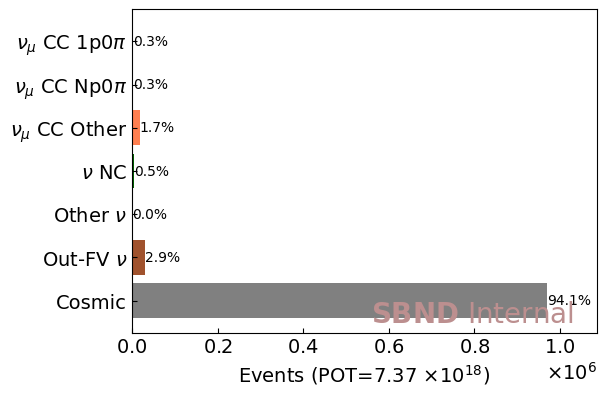

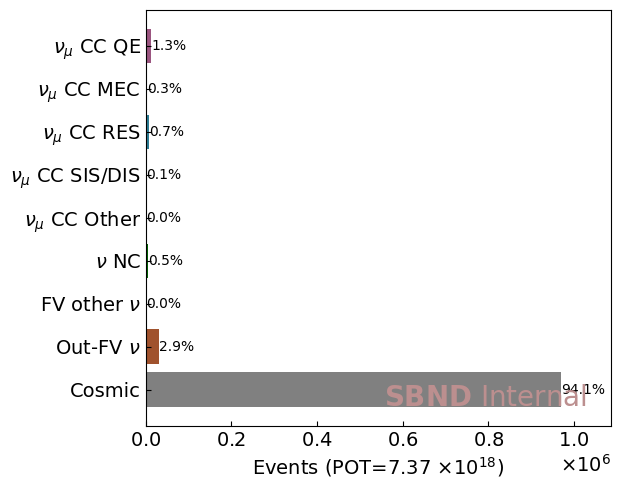

In [8]:
stage_key = "allreco"

mc_df = mc_evt_df
data_df = data_evt_df
intime_df = intime_evt_df
dirt_df = dirt_evt_df

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)

# save dfs
for d, d_dict in zip(
    (mc_df, data_df, intime_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_dirt)
):
    d_dict[stage_key] = d

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

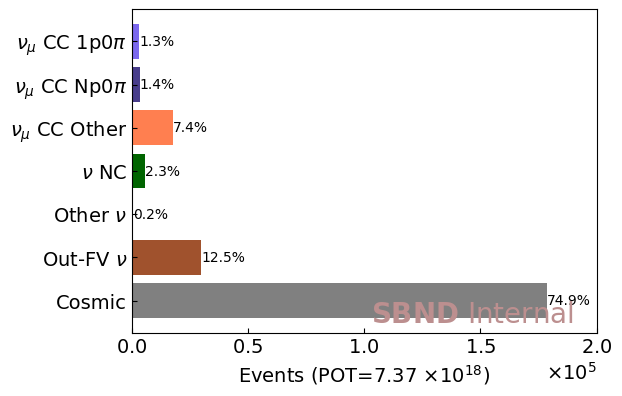

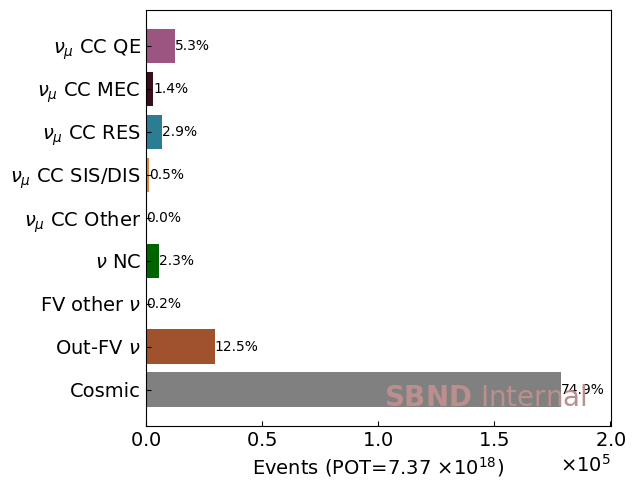

In [9]:
stage_key = "is_clear_cosmic"

# dfs
mc_df, data_df, intime_df, dirt_df = (
    cut_clear_cosmic(df)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)

# save dfs
for d, d_dict in zip(
    (mc_df, data_df, intime_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_dirt)
):
    d_dict[stage_key] = d

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

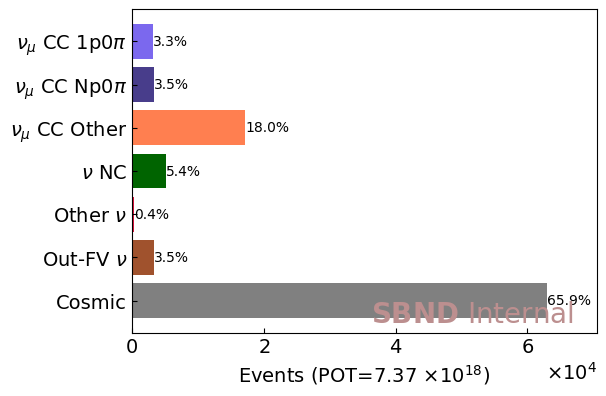

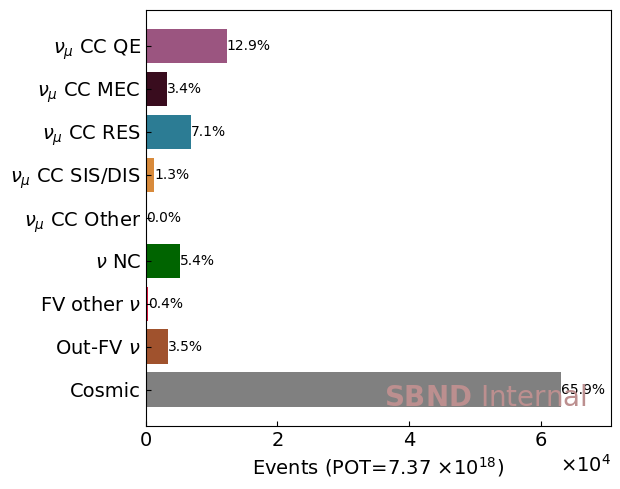

In [10]:
stage_key = "vertex_in_fv"

# dfs
mc_df, data_df, intime_df, dirt_df = (
    cut_vertex_in_fv(df, det=DETECTOR)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_dirt)
):
    d_dict[stage_key] = d

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

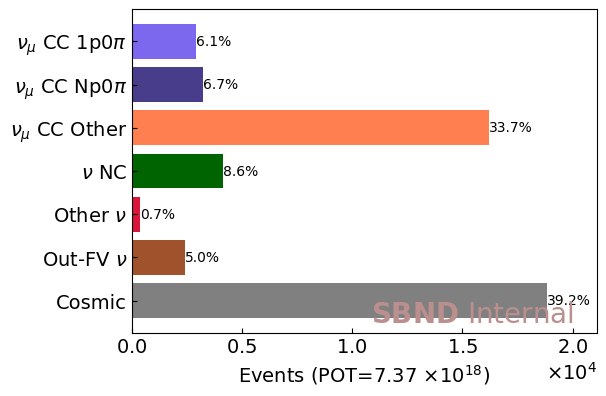

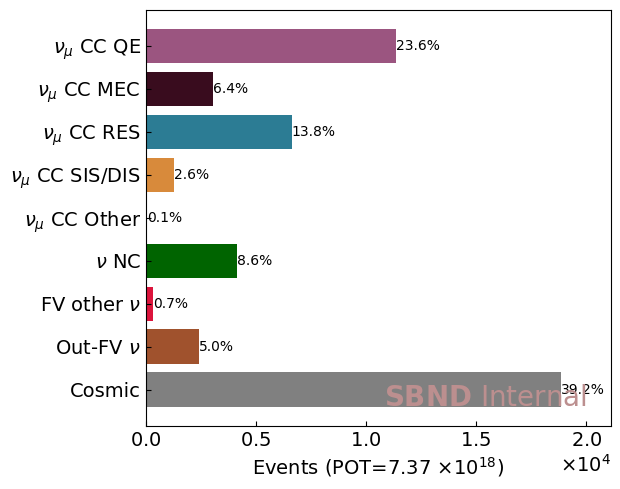

In [11]:
stage_key = "nu_score"

# dfs
mc_df, data_df, intime_df, dirt_df = (
    cut_nu_score(df, NU_SCORE_TH)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_dirt)
):
    d_dict[stage_key] = d

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

## Slice has at least two tracks

In [12]:
mc_trk_df, data_trk_df, intime_trk_df, dirt_trk_df = (
    get_valid_trks(df)
    for df in (mc_trk_df, data_trk_df, intime_trk_df, dirt_trk_df)
)

In [13]:
mc_trk_df, data_trk_df, intime_trk_df, dirt_trk_df = (
    match_trkdf_to_slcdf(trk_df, df)
    for trk_df, df in ((mc_trk_df, mc_df), (data_trk_df, data_df), (intime_trk_df, intime_df), (dirt_trk_df, dirt_df))
)

min, max: -9999.00, 709.79


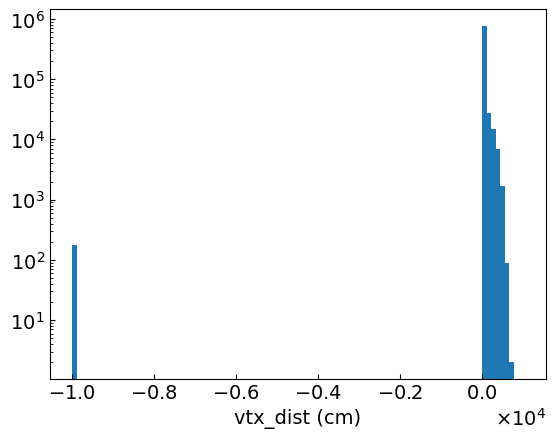

In [14]:
# inspect "good track" cut variables
var = mc_trk_df.pfp.pfochar.vtxdist
print("min, max: %.2f, %.2f" %(var.min(), var.max()))
bins = np.linspace(-1e4, 1e3, 100)
plt.hist(var, bins=bins)
plt.xlabel("vtx_dist (cm)")
plt.yscale("log")
plt.show();

In [15]:
mc_df, data_df, intime_df, dirt_df = (
    get_trk_info(df, trk_df, SAVE_NTRKS)
    for df, trk_df in ((mc_df, mc_trk_df), (data_df, data_trk_df), (intime_df, intime_trk_df), (dirt_df, dirt_trk_df))
)


/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/makedf/selections.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evtdf["n_trks"] = ntrks
/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/makedf/selections.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evtdf["n_good_trks"] = ntrks
/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/makedf/selections.py:51: SettingWithCopyWarn

In [16]:
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
var_config = VariableConfig(
    var_save_name="n_trks",
    var_plot_name="# of Tracks",
    var_labels=[r"", 
    r"", 
    r""],
    bins=np.linspace(1, 5, 5),
    var_evt_reco_col=('n_trks', '', '', '', '', '', ''),
    var_evt_truth_col=('n_trks', '', '', '', '', '', ''),
    var_nu_col=('n_trks', '', ''),
    xsec_label=r""
)

no syst provided


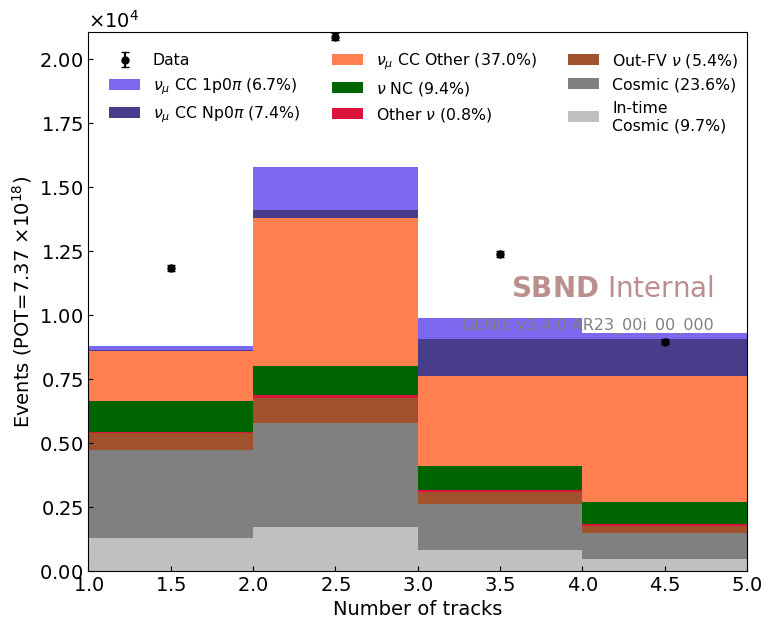

no syst provided


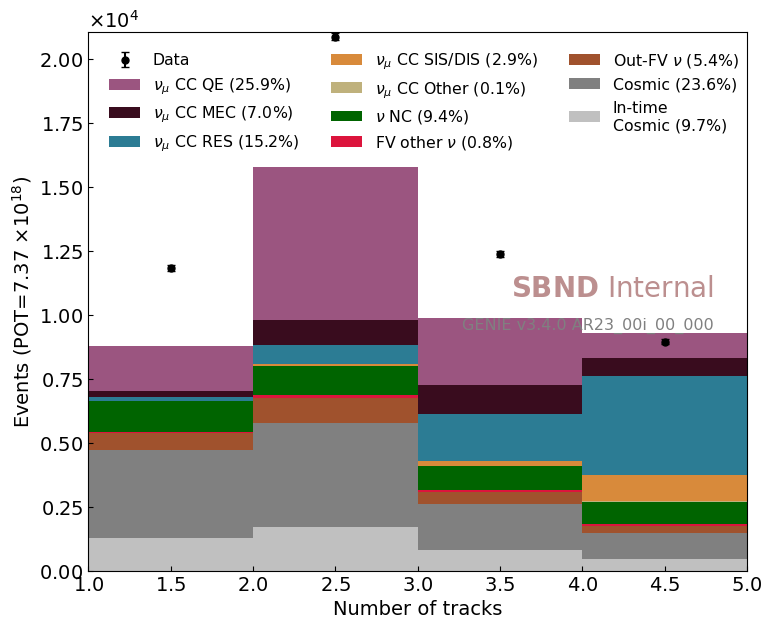

In [20]:
plot_labels = ["Number of tracks", "Events (POT={})".format(pot_str), ""]

for plot_type in ["topology", "genie"]:
    save_name = save_fig_dir + "/selected-{}_{}.png".format("ntrks", plot_type)
    ret_hist_topo = overlay_hists(plot_type,
                                mc_df=mc_df, 
                                data_df=data_df, 
                                intime_df=intime_df, 
                                dirt_df=dirt_df,
                                var_config=var_config,
                                plot_labels=plot_labels,
                                save_fig=save_fig, 
                                save_name=save_name)

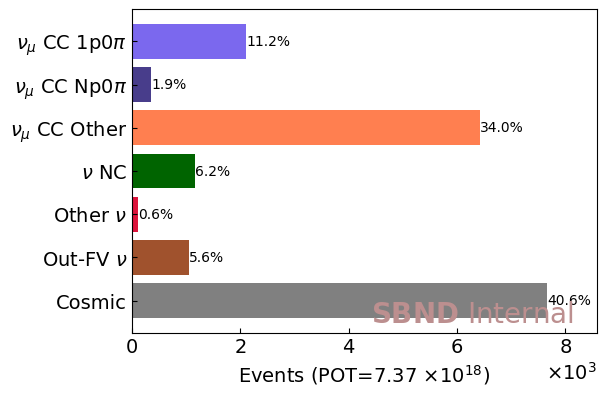

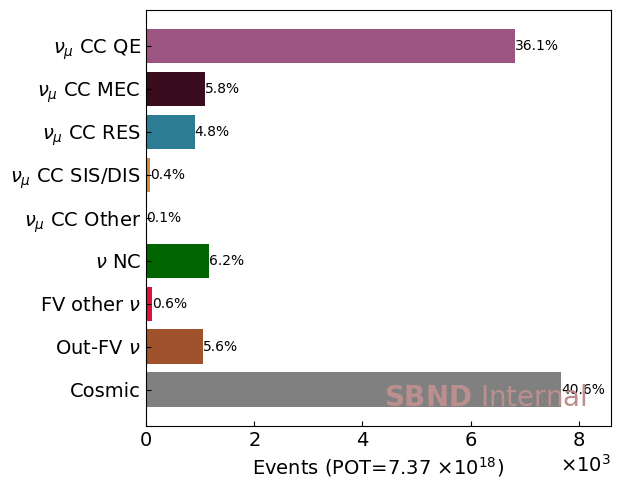

In [21]:
stage_key = "2prong"

# dfs
mc_df, data_df, intime_df, dirt_df = (
    cut_2prong(df)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)

# save dfs
for d, d_dict in zip(
    (mc_df, data_df, intime_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_dirt)
):
    d_dict[stage_key] = d

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

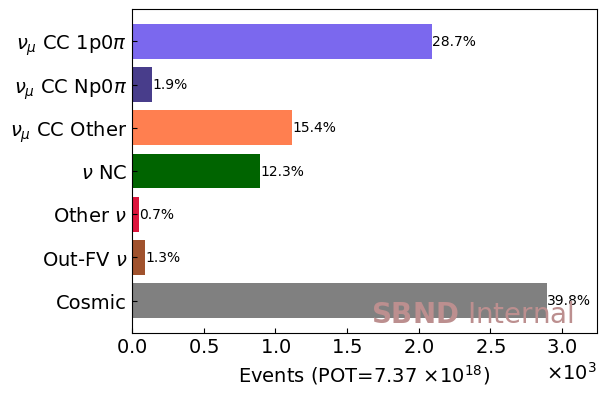

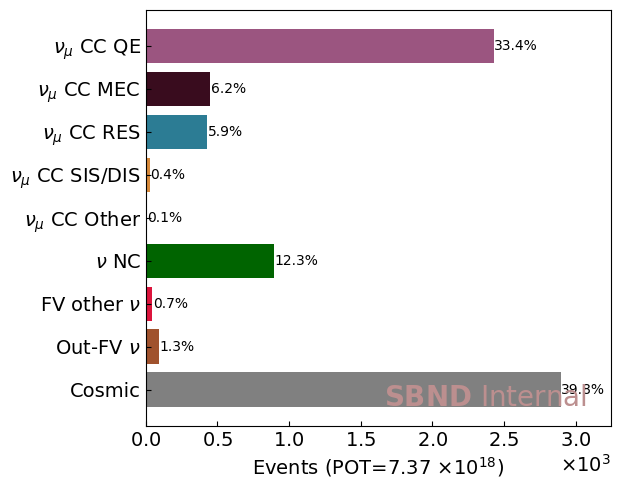

In [22]:
stage_key = "2prong_contained"

# dfs
mc_df, data_df, intime_df, dirt_df = (
    cut_2prong_contained(df, det=DETECTOR)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)

# save dfs
df_dict[stage_key] = mc_df
df_dict_data[stage_key] = data_df
df_dict_intime[stage_key] = intime_df
df_dict_dirt[stage_key] = dirt_df

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

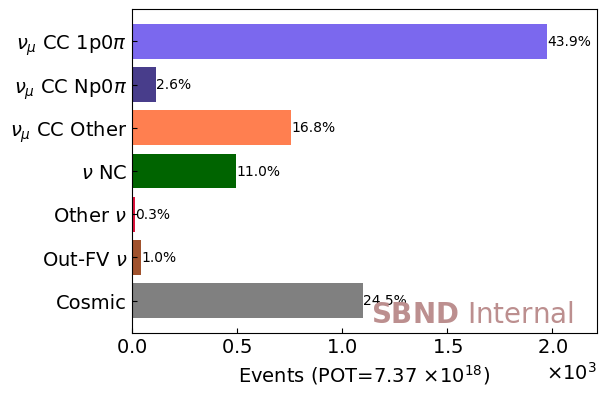

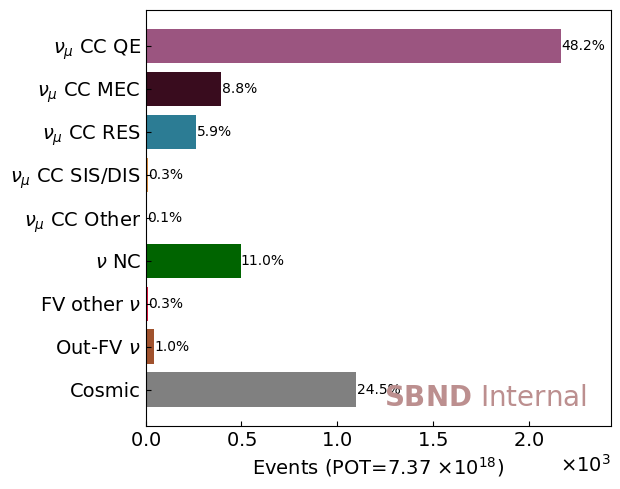

In [23]:
stage_key = "2prong-trackscore"

# dfs
mc_df, data_df, intime_df, dirt_df = (
    cut_2prong_trackscore(df, TRACKSCORE_TH)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)

# save dfs
for d, d_dict in zip(
    (mc_df, data_df, intime_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_dirt)
):
    d_dict[stage_key] = d

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

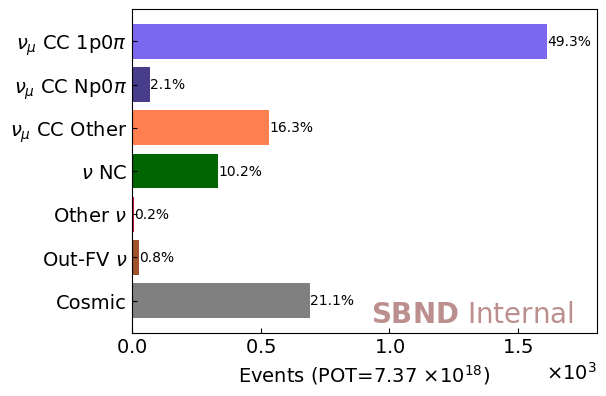

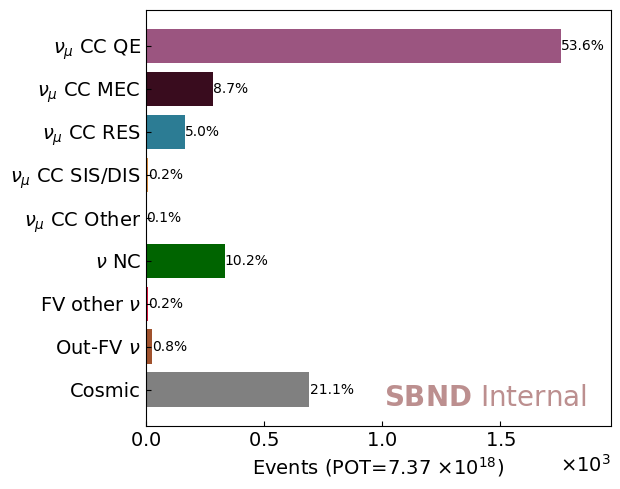

In [24]:
stage_key = "2prong-vtxdist"

# dfs
mc_df, data_df, intime_df, dirt_df = (
    cut_2prong_vtxdist(df, VTXDIST_TH)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)

# save dfs
for d, d_dict in zip(
    (mc_df, data_df, intime_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_dirt)
):
    d_dict[stage_key] = d

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

## PID

In [25]:
mc_df, data_df, intime_df, dirt_df = (
    get_mu_p_candidate(df, 
                       mu_chi2mu_th=MU_CHI2MU_TH, mu_chi2p_th=MU_CHI2P_TH, mu_len_th=MU_LEN_TH, qual_th=QUAL_TH,
                       p_chi2mu_th=-1, p_chi2p_th=P_CHI2P_TH, p_len_th=P_LEN_TH)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

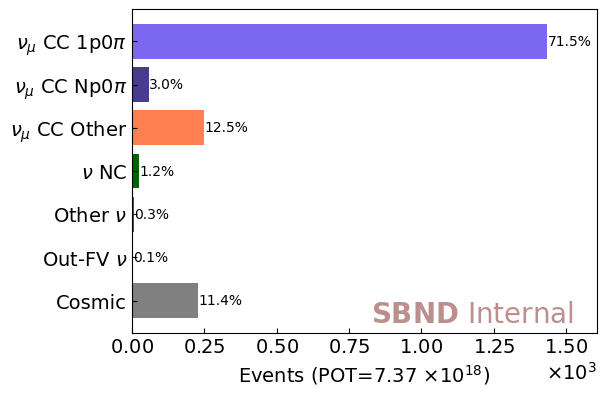

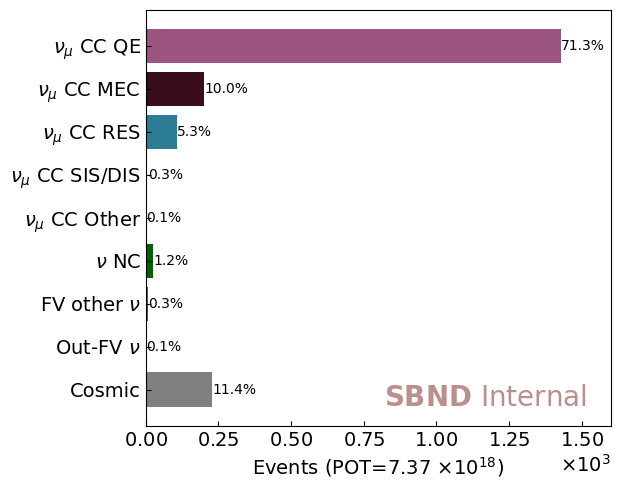

In [26]:
stage_key = "2prong-muX"

# dfs
mc_df, data_df, intime_df, dirt_df = (
    cut_has_mu(df)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

mc_df, data_df, intime_df, dirt_df = (
    cut_mu_kinematics(df, mu_Plo_th=MU_PLO_TH, mu_Phi_th=MU_PHI_TH)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)

# save dfs
for d, d_dict in zip(
    (mc_df, data_df, intime_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_dirt)
):
    d_dict[stage_key] = d

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

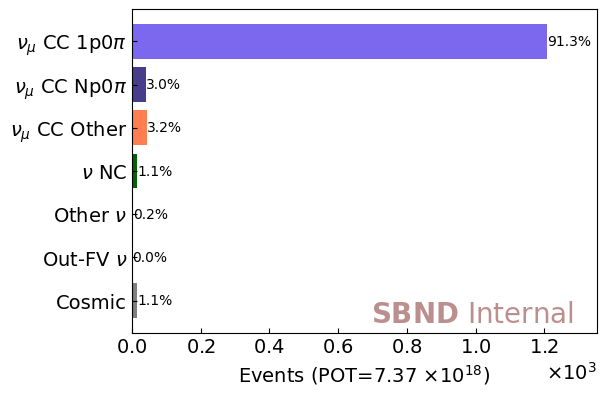

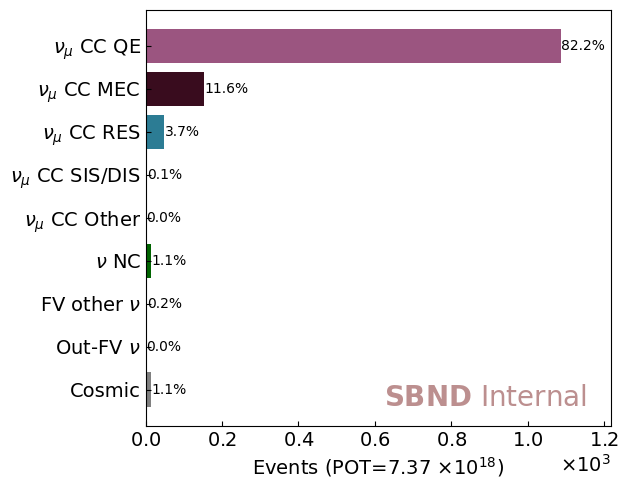

In [27]:
stage_key = "2prong-mup"

# dfs
mc_df, data_df, intime_df, dirt_df = (
    cut_has_p(df)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

mc_df, data_df, intime_df, dirt_df = (
    cut_p_kinematics(df, p_Plo_th=P_PLO_TH, p_Phi_th=P_PHI_TH)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)

# save dfs
for d, d_dict in zip(
    (mc_df, data_df, intime_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_dirt)
):
    d_dict[stage_key] = d

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

In [28]:
stage_labels = [
    "All reconstructed slices",
    "Not clear cosmic",
    "Vertex in fiducial volume",
    "Nu-score > {}".format(NU_SCORE_TH),
    "Has exactly 2 PFPs",
    "Both PFPs contained",
    "Both PFPs have track score > {}".format(TRACKSCORE_TH),
    "Both track \n(start position - vertex) < {} cm".format(VTXDIST_TH),
    "One track is muon-like",
    "The other is proton-like"
]

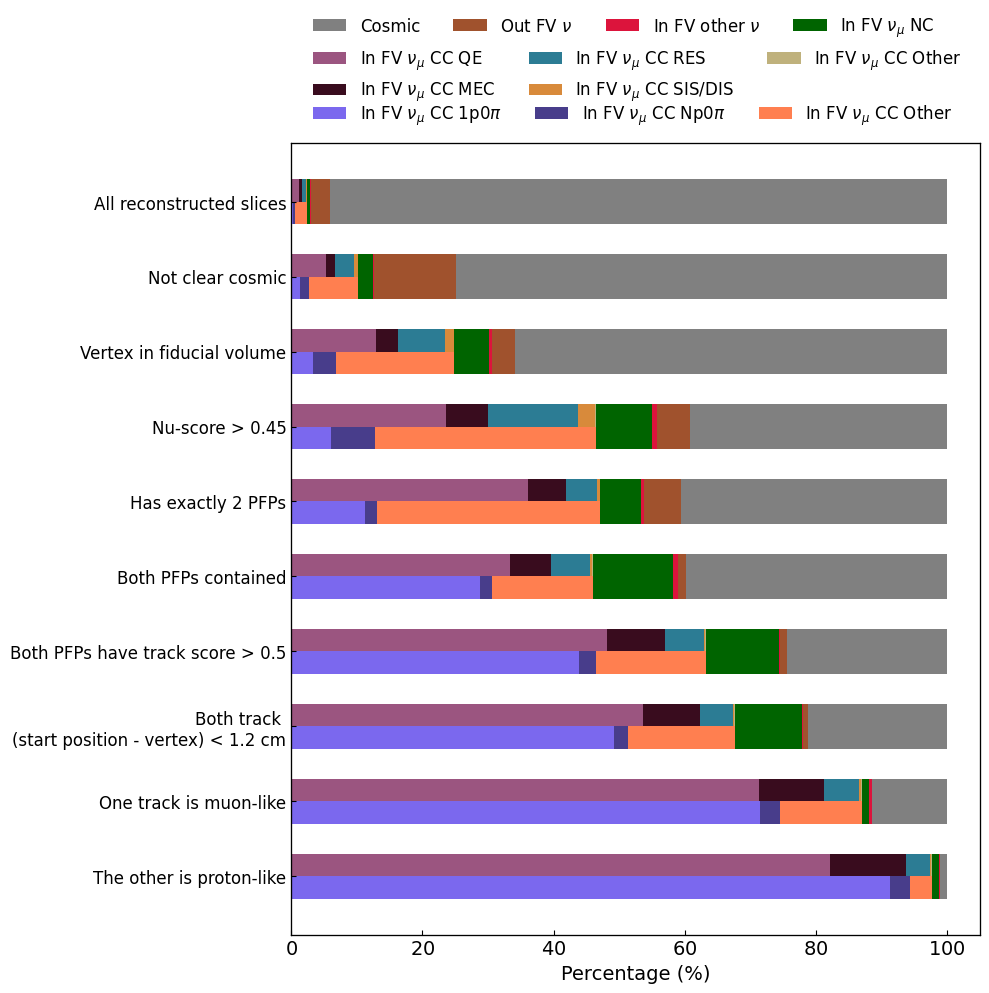

In [29]:
from matplotlib.patches import Patch

stages = list(perc_dict_topo.keys())[::-1]
y = np.arange(len(stages))
bar_width = 0.3

def stack_bars(ax, data, yoffset, colors, label):
    left = np.zeros(len(stages))
    bars = []
    for i, color in enumerate(colors[:data.shape[1]]):
        b = ax.barh(y + yoffset, data[:, i], bar_width, left=left, color=color, label=label if i == 0 else None)
        bars.append(b)
        left += data[:, i]
    return bars

topo_data = np.array([perc_dict_topo[stage] for stage in stages])[:, ::-1]
genie_data = np.array([perc_dict_genie[stage] for stage in stages])[:, ::-1]

fig, ax = plt.subplots(figsize=(10, 10))
stack_bars(ax, topo_data, -bar_width/2, topology_colors, "Topology")
stack_bars(ax, genie_data,  bar_width/2,  genie_mode_colors, "GENIE")

ax.set_xlabel("Percentage (%)")
ax.set_yticks(y)
ax.set_yticklabels(stage_labels[::-1], fontsize=12)

common_patches = [Patch(facecolor=c, label=l) for c, l in zip(
    ["gray", "sienna", "crimson", "darkgreen"],
    ["Cosmic", r"Out FV $\nu$", r"In FV other $\nu$", r"In FV $\nu_{\mu}$ NC"]
)]
genie_patches = [Patch(facecolor=c, label=l) for c, l in zip(
    ["#BFB17C", "#D88A3B", "#2c7c94", "#390C1E", "#9b5580"],
    [r"In FV $\nu_{\mu}$ CC Other", r"In FV $\nu_{\mu}$ CC SIS/DIS", r"In FV $\nu_{\mu}$ CC RES", r"In FV $\nu_{\mu}$ CC MEC", r"In FV $\nu_{\mu}$ CC QE"]
)]
topo_patches = [Patch(facecolor=c, label=l) for c, l in zip(
    ["coral", "darkslateblue", "mediumslateblue"],
    [r"In FV $\nu_{\mu}$ CC Other", r"In FV $\nu_{\mu}$ CC Np0$\pi$", r"In FV $\nu_{\mu}$ CC 1p0$\pi$"]
)]

ax.legend(handles=common_patches, loc='upper left', bbox_to_anchor=(0.01,1.18), ncol=4, fontsize=12, frameon=False)
for i, handles in enumerate([genie_patches[::-1], topo_patches[::-1]]):
    ax_i = ax.twinx()
    ax_i.legend(handles=handles, loc='upper left', 
                bbox_to_anchor=(0.01, 1.14 - 0.07*i), # space out
                ncol=3 if i==0 else 4, fontsize=12, frameon=False)
    ax_i.set_yticks([])

if save_fig:
    plt.savefig(f"{save_fig_dir}/event_selection_summary.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

no syst provided
No syst provided


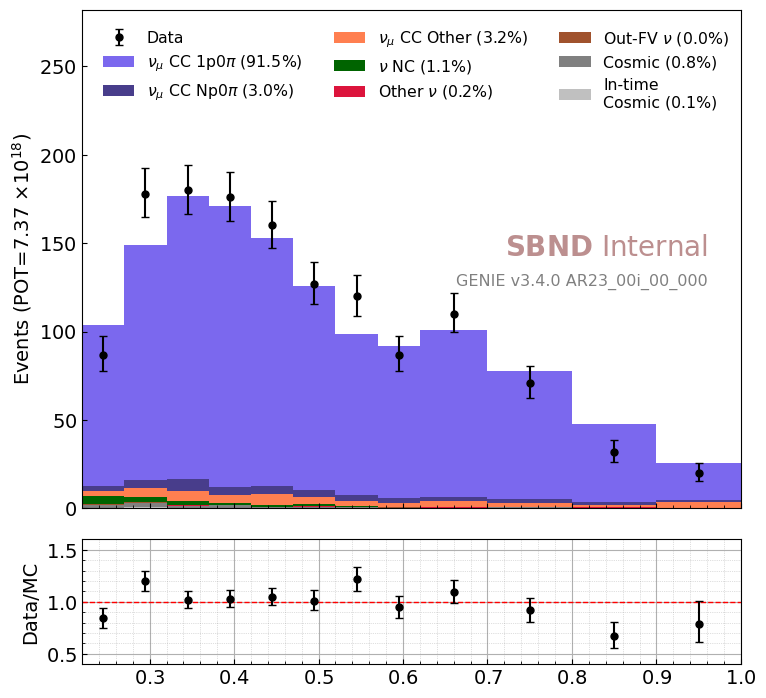

In [30]:
eps = 1e-8
ratio = True
approval = "internal"
textloc = [0.05, 0.55]
ax_ylim_ratio = 1.6
breakdown_type = "topology"

ret = overlay_hists(breakdown_type=breakdown_type,
                    var_config=VariableConfig.muon_momentum(),
                    mc_df=mc_df,
                    data_df=data_df,
                    intime_df=intime_df,
                    ax_ylim_ratio=ax_ylim_ratio,
                    ratio=ratio,
                    textloc=textloc,
                    approval=approval,
                    plot_labels=plot_labels_hist,
                    syst=None,
                    save_fig=False, 
                    save_name=None)

# Efficiency Curves

final purity: 91.58%


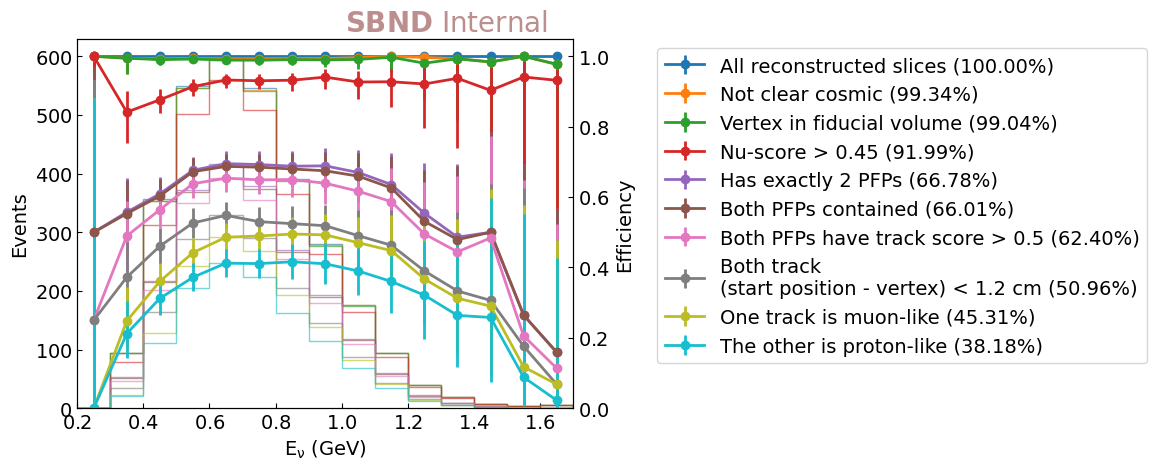

In [44]:
var_config = VariableConfig.neutrino_energy()
plot_efficiency(df_dict,
                stage_labels,
                var_config, 
                textloc=[0.05, 1.08],
                approval="internal", 
                legend=True,
                save_fig=False, 
                save_name=None)

final purity: 91.58%


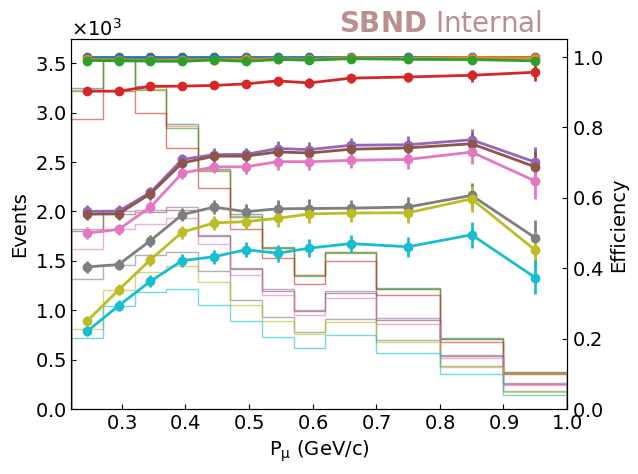

final purity: 91.58%


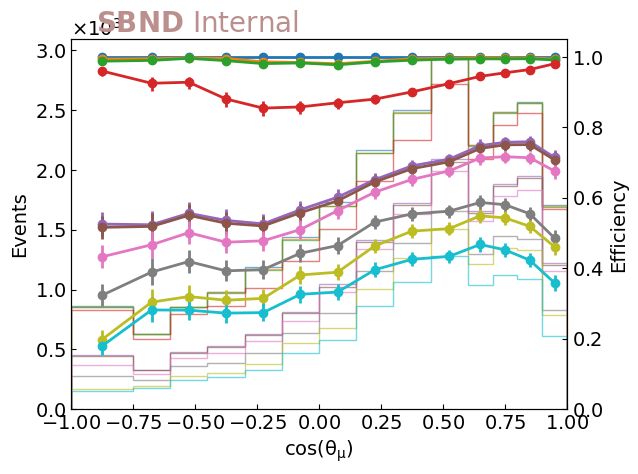

final purity: 91.58%


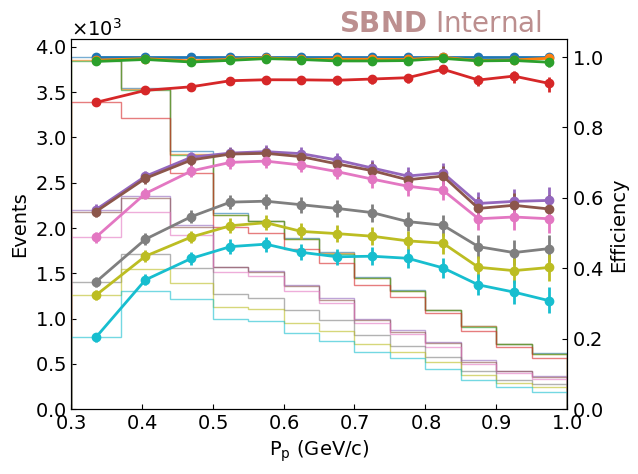

final purity: 91.58%


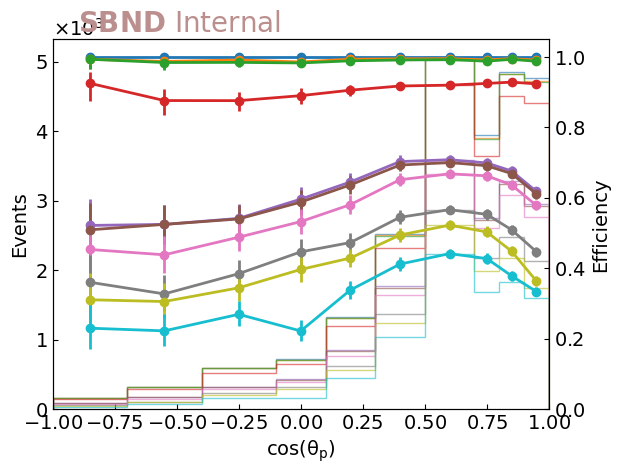

In [32]:
for var_config in [VariableConfig.muon_momentum(), VariableConfig.muon_direction(),
                   VariableConfig.proton_momentum(), VariableConfig.proton_direction()]:
                #    VariableConfig.opening_angle(),
                #    VariableConfig.tki_del_Tp(), VariableConfig.tki_del_p(),
                #    VariableConfig.tki_del_alpha(), VariableConfig.tki_del_phi(),]:

    plot_efficiency(df_dict,
                    stage_labels,
                    var_config, 
                    textloc=[0.05, 1.08],
                    approval="internal", 
                    legend=False,
                    save_fig=False, 
                    save_name=None)